## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

from sklearn.datasets import make_moons
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Generate Data

In [2]:
X, y = make_moons(256, noise=0.1, random_state=42)

df = pd.DataFrame({"x0": X[:,0], "x1": X[:,1], "y": y})

df

,x0,x1,y
0,1.770779,-0.057636,1
1,1.113900,0.154442,0
2,-0.257176,1.014721,0
3,1.371609,-0.580707,1
4,-1.072331,0.318978,0
...,...,...,...
251,-0.959604,0.521036,0
252,1.045807,0.314699,0
253,-0.654584,0.842351,0
254,0.779745,-0.456423,1


#### Convert Data to Tensors

In [3]:
X = torch.tensor(X, dtype = torch.float32)
y = torch.tensor(y, dtype=torch.int64)

#### Plot Data

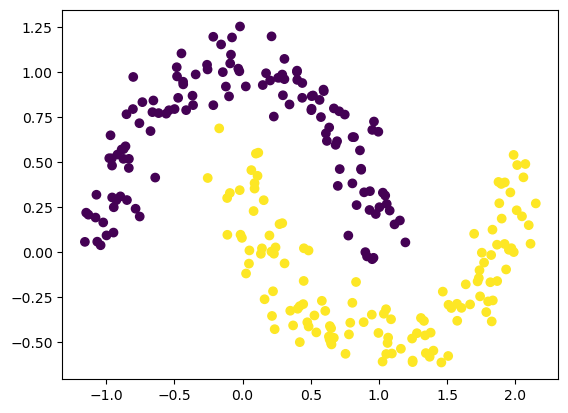

In [4]:
plt.scatter(X[:,0], X[:,1], c=y);

## Section 1: Organizing Code for Readability and Reusability: Functions

Whether you're writing code in a jupyter notebook or in a script, eventually your code will get long enough that it becomes a challenge to keep it understandable. Furthermore, you may want to reuse a useful piece of code in another project. A good way to make your code easy to read, maintain, and reuse is to organize it into smaller functions. A function has the following structure:

```python
def function_name(argument1, argument2, argument3, ...):
    code that does something goes here
    return output
```

For example, a function that adds two numbers together might look like this:

```python
def add_two_numbers(number1, number2):
    result = number1 + number2
    return result
```

The common components of a function are:

- A name that can be used to call it when you want to use it (e.g. "add_two_numbers")
- The inputs (a.k.a "arguments", e.g. "number1", "number2") that the function needs to do its work
- The output (a.k.a. "return value", e.g. "result") that the function will give to whatever code that called it

Arguments and a return values are not always needed, however, it depends on what you need the function to do.

When you use a function in Python, first, you write the function name, then you pass the arguments to that function inside round brackets. Each argument is separated by a comma. Below are three examples of how a function can be used: one where the function takes no arguments, one where it takes a single argument, and one where it takes three arguments.

```python
>>> function_name()
>>> function_name(argument1)
>>> function_name(argument1, argument2, argument3)
```

In the exercises in this section, you will get some practice writing functions.

| Code | Description |
|---|---|
| `len(array)` | Returns the length - the number of elements - in ``array``. |
| `sum(numbers)` | Returns the sum of all elements in `numbers`. |


#### **Exercises**

**Example**: Create a function called `add` that adds two numbers and returns the result.

In [5]:
def add(x, y):   # Define a function name and its arguments x and y
    z = x + y    # Make calculations in the function body
    return z     # "Return" data out of the function.

In [6]:
result = add(5, 3)  # Then the function can be called again, changing the argument values for whatever you want!
result

8

**Exercise**: Create a function called `multiply` that multiplies two numbers and returns the result. Run the cell with the provided code below to check if your function gives you the correct result.

In [7]:
def multiply(x, y):   # Define a function name and its arguments x and y
    z = x * y    # Make calculations in the function body
    return z     # "Return" data out of the function.

In [8]:
result = multiply(2,3)
result

6

**Exercise**: Create a function called `divide` that takes two numbers `a` and `b` and divides one by the other. Run the cell with the provided code below to check if your function gives you the correct result.

In [9]:
def divide(a, b):
    result = a / b
    return result

In [10]:
a = 10
b = 2
result = divide(a, b)
result

5.0

**Exercise**: Create a function called `calculate_mean` that takes a list of numbers as input and returns the mean. 

**Hint**: The reference table contains useful code for this function.

Run the cell with the provided code below to check if your function gives you the correct result.

In [11]:
def calculate_mean(numbers):
    total = sum(numbers)
    mean = total / len(numbers)
    return mean

In [12]:
numbers = [5, 9, 16]
result = calculate_mean(numbers)
result

10.0

---

#### Packaging Code into Functions as Refactoring

Because writing functions is often done during a refactoring (reorganizing) process in writing code, let's practice refactoring by taking code that already works and changing it into a function.

**Example**: Make a function out of the code in the first cell below and check that the function gives correct result.

In [13]:
a = 5
b = 3
result = a - b
result

2

In [14]:
def subtract(a, b):
    result = a - b
    return result

In [15]:
# check that the function gives the correct result
result = subtract(5, 3)
result

2

**Exercise**: Make a function out of the code in the first cell below and check that the function gives correct result with the same numbers.

In [16]:
numbers = [1, 2, 3, 4, 5]
mean = calculate_mean(numbers)
variance = sum([(x - mean) ** 2 for x in numbers]) / len(numbers)
std = variance ** 0.5
std

1.4142135623730951

In [17]:
def calculate_std(numbers):
    mean = calculate_mean(numbers)
    variance = sum([(x - mean) ** 2 for x in numbers]) / len(numbers)
    std = variance ** 0.5
    return std

numbers = [1, 2, 3, 4, 5]
calculate_std(numbers)

1.4142135623730951

## Section 2: Put Training of Neural Networks into Functions

In this section, we will turn the code that we use to train a neural network into functions. This allows us to reuse it later and helps you avoid code repetition.

| Code | Description |
| --- | --- |
| `loss_function(y_net, y_true)` | Calculates the loss between the y_net of the network `y_net` and the true y-values from the data `y_true`. |
| `loss_function(y_net, y_true).item()` | Extracts the loss value (the number alone as a ``float`` and not as a ``tensor`` type). |
| `optim.SGD(net.parameters())` | Creates a stochastic gradient descent (SGD) optimizer. |
| `optimizer = optim.SGD(net.parameters())` | Creates a stochastic gradient descent (SGD) optimizer and assigns it to a variable called `optimizer`. |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |

In [18]:
SEED = 42
torch.manual_seed(SEED)

net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

n_samples = 80
X_samples = X[:n_samples]
y_true = y[:n_samples]

**Example**: Turn the code below where the input `X_samples` is passed to the network into a function called `forward_pass`* that takes an input `x` and returns the ``y_net`` from the network. Check that you get the same output from the function as you do without the function.

*Passing input to a network that then returns an output is referred to as a "forward pass" in the deep learning literature.

In [19]:
y_net = net(X_samples)
y_net

tensor([[ 0.2759,  0.3435],
        [ 0.1586,  0.0792],
        [-0.2391, -0.6694],
        [ 0.1299,  0.2777],
        [-0.3268, -0.8778],
        [ 0.0390, -0.0239],
        [ 0.3604,  0.3994],
        [ 0.0031, -0.1932],
        [ 0.1422,  0.0306],
        [ 0.0588, -0.2122],
        [ 0.0713,  0.0273],
        [ 0.2477,  0.3598],
        [ 0.2532,  0.3803],
        [ 0.2137,  0.3237],
        [-0.0886, -0.5380],
        [-0.1392, -0.5129],
        [ 0.1067,  0.1628],
        [ 0.1194, -0.0869],
        [-0.3603, -0.8661],
        [ 0.0874, -0.1151],
        [ 0.3241,  0.3983],
        [ 0.0603, -0.1402],
        [-0.2771, -0.7952],
        [-0.0108, -0.3683],
        [ 0.1129, -0.1096],
        [-0.2680, -0.8102],
        [ 0.3814,  0.3706],
        [ 0.1356,  0.3026],
        [ 0.1291,  0.0139],
        [ 0.0063, -0.2137],
        [ 0.0414,  0.0263],
        [-0.3712, -0.8874],
        [ 0.0029, -0.3173],
        [ 0.0697,  0.1658],
        [ 0.2101,  0.3099],
        [ 0.0602, -0

In [20]:
def forward_pass(x):
    y_net = net(x)
    return y_net

In [21]:
y_net = forward_pass(X_samples)
y_net

tensor([[ 0.2759,  0.3435],
        [ 0.1586,  0.0792],
        [-0.2391, -0.6694],
        [ 0.1299,  0.2777],
        [-0.3268, -0.8778],
        [ 0.0390, -0.0239],
        [ 0.3604,  0.3994],
        [ 0.0031, -0.1932],
        [ 0.1422,  0.0306],
        [ 0.0588, -0.2122],
        [ 0.0713,  0.0273],
        [ 0.2477,  0.3598],
        [ 0.2532,  0.3803],
        [ 0.2137,  0.3237],
        [-0.0886, -0.5380],
        [-0.1392, -0.5129],
        [ 0.1067,  0.1628],
        [ 0.1194, -0.0869],
        [-0.3603, -0.8661],
        [ 0.0874, -0.1151],
        [ 0.3241,  0.3983],
        [ 0.0603, -0.1402],
        [-0.2771, -0.7952],
        [-0.0108, -0.3683],
        [ 0.1129, -0.1096],
        [-0.2680, -0.8102],
        [ 0.3814,  0.3706],
        [ 0.1356,  0.3026],
        [ 0.1291,  0.0139],
        [ 0.0063, -0.2137],
        [ 0.0414,  0.0263],
        [-0.3712, -0.8874],
        [ 0.0029, -0.3173],
        [ 0.0697,  0.1658],
        [ 0.2101,  0.3099],
        [ 0.0602, -0

**Exercise**: Turn the code below where the class is predicted from the output of the network into a function called `predict`. It needs to take the `y_net` from the network as an argument and return the predicted classes. Check that you get the same result from the function as you do without the function.

In [22]:
prediction = torch.argmax(y_net, dim=1)
prediction

tensor([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 0])

In [23]:
def predict(y_net):
    prediction = torch.argmax(y_net, dim=1)
    return prediction

In [24]:
predict(y_net)

tensor([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 0])

In the `forward_pass` function above, the net is used inside the function without being provided as input to the function. This works fine as long as the network is named `net`. However, if you have named it `model` or `network` or something else, the function won't work. Therefore, it's often a good idea to provide the network as an input argument to the function as well and just use the argument name for the network inside the function. That way, the function will not be confused about which model you mean when you use it.

**Exercise**: Create a new `forward_pass` function just named `forward` that takes **two** arguments: `x` and `model`. Note that `model` has to be used instead of `net` inside the function. Run the provided code below that calls the function to check that it still gives the same result. 

In [ ]:
def forward(x, model):
    y_net = model(x)
    return y_net

In [ ]:
y_net = forward(x = X_samples, model = net)
y_net

tensor([[ 0.2759,  0.3435],
        [ 0.1586,  0.0792],
        [-0.2391, -0.6694],
        [ 0.1299,  0.2777],
        [-0.3268, -0.8778],
        [ 0.0390, -0.0239],
        [ 0.3604,  0.3994],
        [ 0.0031, -0.1932],
        [ 0.1422,  0.0306],
        [ 0.0588, -0.2122],
        [ 0.0713,  0.0273],
        [ 0.2477,  0.3598],
        [ 0.2532,  0.3803],
        [ 0.2137,  0.3237],
        [-0.0886, -0.5380],
        [-0.1392, -0.5129],
        [ 0.1067,  0.1628],
        [ 0.1194, -0.0869],
        [-0.3603, -0.8661],
        [ 0.0874, -0.1151],
        [ 0.3241,  0.3983],
        [ 0.0603, -0.1402],
        [-0.2771, -0.7952],
        [-0.0108, -0.3683],
        [ 0.1129, -0.1096],
        [-0.2680, -0.8102],
        [ 0.3814,  0.3706],
        [ 0.1356,  0.3026],
        [ 0.1291,  0.0139],
        [ 0.0063, -0.2137],
        [ 0.0414,  0.0263],
        [-0.3712, -0.8874],
        [ 0.0029, -0.3173],
        [ 0.0697,  0.1658],
        [ 0.2101,  0.3099],
        [ 0.0602, -0

**Exercise**: Turn the code below that trains the network into a function `train_epochs` that takes a single input `n_epochs` that sets how many epochs to train for and returns the `losses` variable containing a list of the loss in each epoch. Remember to remove the setting of `n_epochs` inside the function.

In [27]:
optimizer = torch.optim.SGD(net.parameters())

loss_function = nn.CrossEntropyLoss()

losses = []

n_epochs = 5
for epoch in range(n_epochs):

    optimizer.zero_grad()

    y_net = net(X_samples)

    loss = loss_function(y_net, y_true)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

In [28]:
def train_epochs(n_epochs):
    optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

    loss_function = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(n_epochs):

        optimizer.zero_grad()

        y_net = net(X_samples)

        loss = loss_function(y_net, y_true)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return losses

**Exercise**: Turn the code below that calculates the accuracy into a function called `calculate_accuracy`.

In [31]:
prediction = torch.argmax(y_net, dim=1)
accuracy = (prediction == y_true).sum()/len(y_true)
accuracy

tensor(0.7500)

In [32]:
def calculate_accuracy(predicted_classes, true_classes):
    accuracy = (predicted_classes == true_classes).sum()/len(true_classes)
    return accuracy

## Section 3: 

You may have noticed above that in the call of the `forward` function the arguments were passed by setting them equal to a variable, like so:

```python
y_net = forward(x = X_samples, model = net)
```

If you don't do this, you have to pass the arguments in the correct order in the function call for the function to know what's what. When the function only takes a few arguments, that's usually not that hard (though it can still be a source of error if you're not careful). But if your function has more arguments, it's often a good idea to use the equal sign in the function call to make it clear which value belongs to which argument. In this section, you'll get some practice doing this.

| Code | Description |
| --- | --- |
| `def function_name(arg1, arg2):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `# do some operation here` <br> &nbsp;&nbsp;&nbsp;&nbsp; `return result`| Defines function `function_name`. |
| `def function_name(arg1, ` <br> &nbsp;&nbsp;&nbsp;&nbsp; `arg2 = some_default_value):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `# do some operation here` <br> &nbsp;&nbsp;&nbsp;&nbsp; `return result`| Defines function `function_name` and sets default values for `arg2`. This argument then doesn't need to be specified in the function call unless you want to set it to a different value than the default. | 
| `function_name(some_value, ` <br> &nbsp;&nbsp;&nbsp;&nbsp; `some_value`<br>`)` | Calls `function_name` and specifies the value of ``arg1`` and `arg2` by passing them in the right order (the value of `arg1` before the value of `arg2`) | 
| `function_name(` <br> &nbsp;&nbsp;&nbsp;&nbsp; `arg2 = some_value, ` <br> &nbsp;&nbsp;&nbsp;&nbsp; `arg1 = some_value` <br> `)` | Calls `function_name` and specifies the value of `arg1` and `arg2` by setting them `=` to a value in the call. Note that the order now doesn't matter, `arg2` can be placed before `arg1`. | 


#### **Exercises**

**Exercise**: Create a new function called `train` that does the same thing as `train_epochs` above, but takes five input arguments: `n_epochs`, `model`, `X_samples`, `optimizer`, and `loss_function`. By writing the function this way, the optimizer, loss function, model, or input data can be changed simply by changing the arguments passed to the function. Otherwise, one would need to change the code inside the function.

 Run the provided code below that calls the function to check that it still gives the same result. 

In [ ]:
def train(n_epochs, model, X_samples, optimizer, loss_function):

    losses = []
    for epoch in range(n_epochs):

        optimizer.zero_grad()

        y_net = model(X_samples)

        loss = loss_function(y_net, y_true)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return losses

In [ ]:
losses = train(n_epochs=5, model=net, X_samples=X_samples, optimizer=torch.optim.SGD(net.parameters(), lr=0.1), loss_function=nn.CrossEntropyLoss())
losses

[0.6251248121261597,
 0.5886311531066895,
 0.5608310103416443,
 0.5385316610336304,
 0.5198858380317688]